In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from numpy import asarray
from numpy.random import randn
from numpy.random import randint
from tensorflow.keras.models import load_model
import numpy as np

In [3]:
import os
import json
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
import cv2
import albumentations as A
from skimage.io import imread
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

In [4]:
zip_file_path = '/content/drive/MyDrive/Cond_gan/gan-training-256by256.zip'
extract_folder = '/content/drive/MyDrive/Cond_gan/unzip'  # Change this to your desired destination folder
base_folder='/content/drive/MyDrive/Cond_gan'


In [5]:
import zipfile
try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_folder)
    print("Unzip operation executed successfully.")
except Exception as e:
    print(f"Error: {e}")


Unzip operation executed successfully.


In [ ]:
zip_file_path='/content/drive/MyDrive/Cond_gan/cheakpoint-20231031T142713Z-001.zip'

In [ ]:
#unzip cheakpoint
import zipfile
try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(base_folder)
    print("Unzip operation executed successfully.")
except Exception as e:
    print(f"Error: {e}")


Unzip operation executed successfully.


In [6]:
folder_path = extract_folder
dirs = os.listdir(folder_path)

print(dirs)

['Banana_Immature', 'Banana_Mature', 'Banana_Semi-mature', 'Guava_Immature', 'Guava_Mature', 'Guava_Semi-mature', 'Lemon-Immature', 'Lemon_Mature', 'Lemon_Semi-mature', 'Mango_Immature', 'Mango_Mature', 'Mango_Semimature', 'Papaya_Immature', 'Papaya_Mature', 'Papaya_Semi-mature', 'Tomato_Immature', 'Tomato_Mature', 'Tomato_Semi-mature']


In [7]:
for i in range(len(dirs)):
    types = set()
    for n in os.listdir(os.path.join(folder_path, dirs[i])):
        types.add(n.split('.')[-1])
    print(dirs[i] + ':', types)

Banana_Immature: {'jpg'}
Banana_Mature: {'jpg'}
Banana_Semi-mature: {'jpg'}
Guava_Immature: {'jpg'}
Guava_Mature: {'jpg'}
Guava_Semi-mature: {'jpg'}
Lemon-Immature: {'jpg'}
Lemon_Mature: {'jpg'}
Lemon_Semi-mature: {'jpg'}
Mango_Immature: {'jpg'}
Mango_Mature: {'jpg'}
Mango_Semimature: {'jpg'}
Papaya_Immature: {'jpg'}
Papaya_Mature: {'jpg'}
Papaya_Semi-mature: {'jpg'}
Tomato_Immature: {'jpg'}
Tomato_Mature: {'jpg'}
Tomato_Semi-mature: {'jpg'}


In [8]:
for i in range(len(dirs)):
    class_folder = os.path.join(folder_path, dirs[i])
    files_path = os.listdir(class_folder)
    size = set()

    #fp = files_path
    for fp in files_path:
        img = imread(os.path.join(class_folder, fp))
        size.add(img.shape)

    print('(Height, Width, Channels)')
    print(70*'-')
    print(dirs[i] + ':', size)

(Height, Width, Channels)
----------------------------------------------------------------------
Banana_Immature: {(128, 128, 3)}
(Height, Width, Channels)
----------------------------------------------------------------------
Banana_Mature: {(256, 256, 3)}
(Height, Width, Channels)
----------------------------------------------------------------------
Banana_Semi-mature: {(128, 128, 3)}
(Height, Width, Channels)
----------------------------------------------------------------------
Guava_Immature: {(256, 256, 3)}
(Height, Width, Channels)
----------------------------------------------------------------------
Guava_Mature: {(256, 256, 3)}
(Height, Width, Channels)
----------------------------------------------------------------------
Guava_Semi-mature: {(256, 256, 3)}
(Height, Width, Channels)
----------------------------------------------------------------------
Lemon-Immature: {(256, 256, 3)}
(Height, Width, Channels)
------------------------------------------------------------------

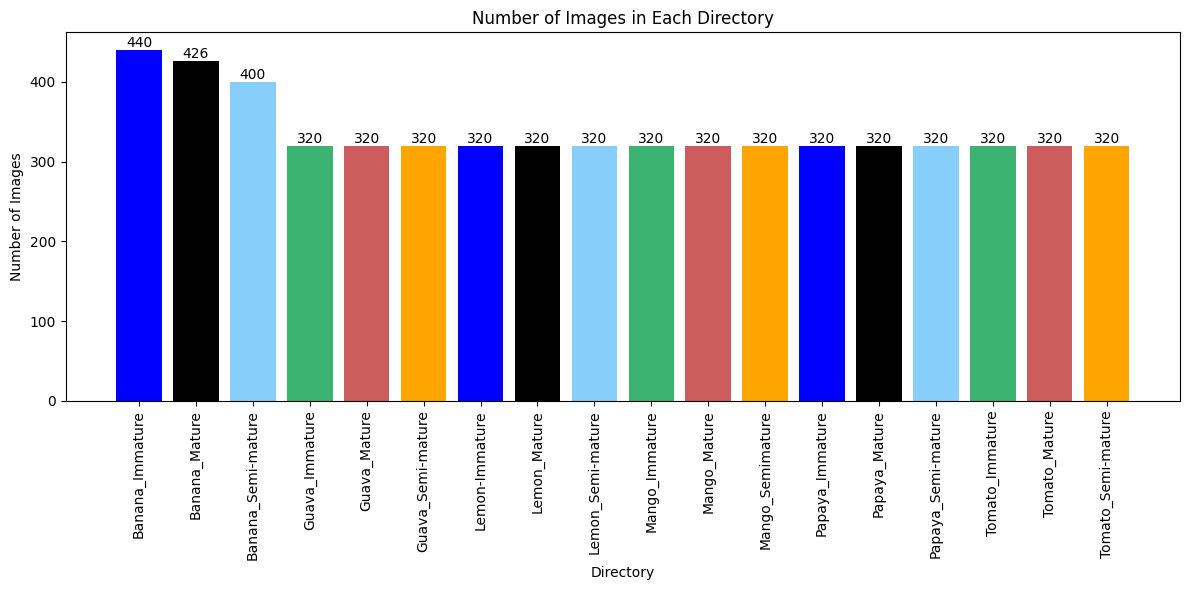

In [9]:
image_counts = []
for directory in dirs:
    sub_dir = os.path.join(folder_path, directory)
    if os.path.isdir(sub_dir):
        file_count = len(os.listdir(sub_dir))
        image_counts.append(file_count)


plt.figure(figsize=(12,6))
for i in range(len(dirs)):
    plt.text(i, image_counts[i], str(image_counts[i]), ha='center', va='bottom')


colors = ['blue','black','lightskyblue', 'mediumseagreen', 'indianred', 'orange']


plt.bar(dirs, image_counts, color=colors)
plt.xlabel('Directory')
plt.xticks(rotation=90)
plt.ylabel('Number of Images')
plt.title('Number of Images in Each Directory')
plt.tight_layout()
plt.show()

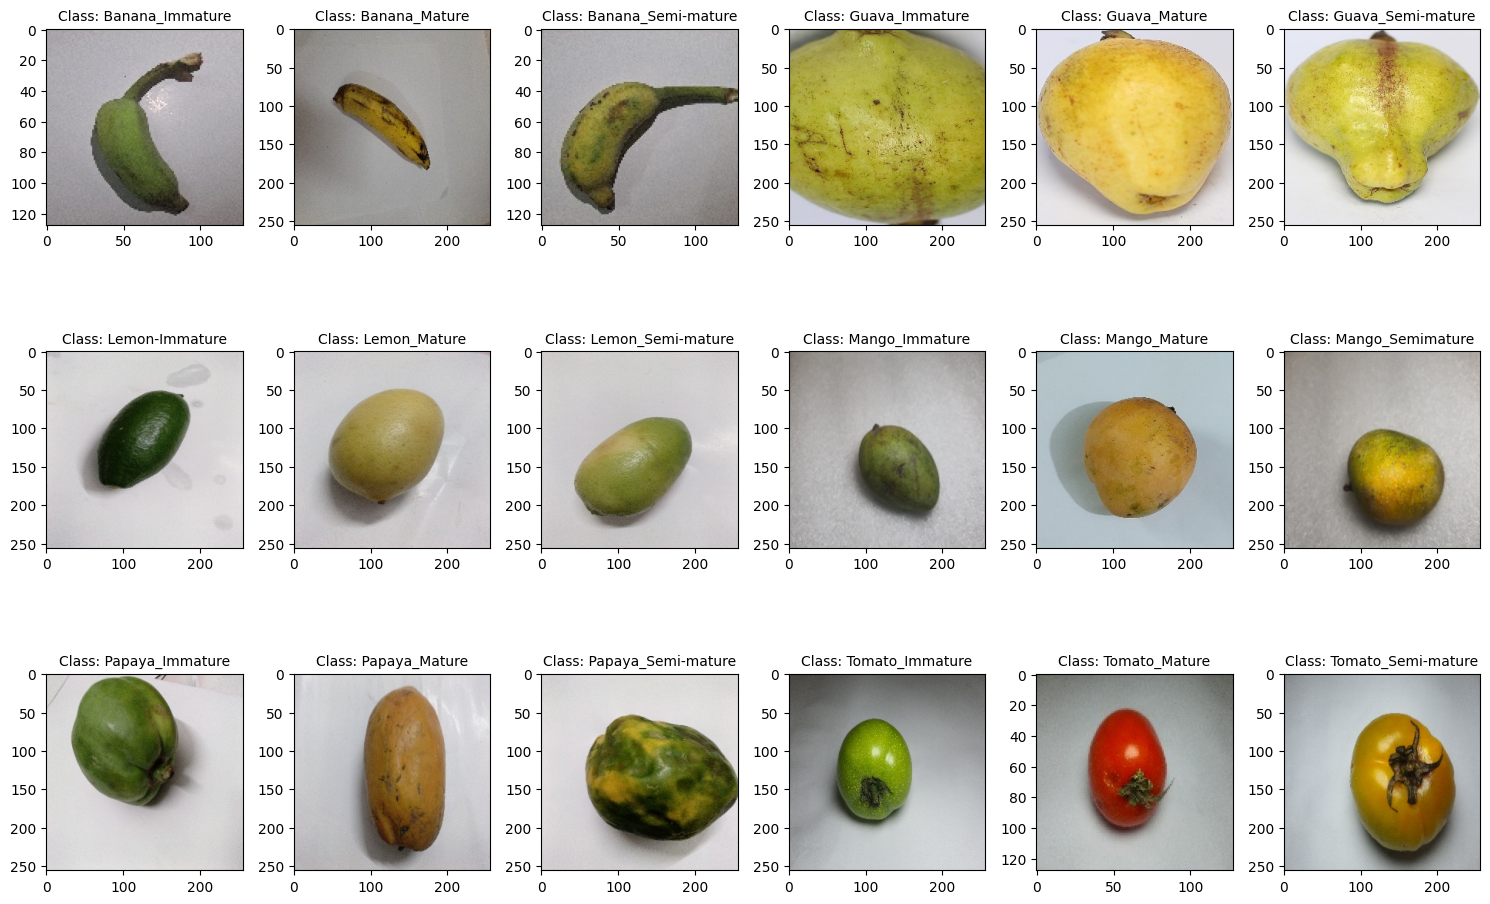

In [10]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Set the path to the parent directory containing class folders
parent_directory = folder_path

# Get a list of class folders (assuming folder names correspond to class names)
class_folders = os.listdir(parent_directory)

# Define the number of images to print from each class (in this case, 1)
num_images_to_print = 1

# Calculate the number of rows and columns for the subplots
num_rows = 3
num_cols = 6

# Calculate the total number of subplots
total_subplots = num_rows * num_cols

# Create a single figure with subplots
fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 10))

# Iterate through each class folder
for idx, class_folder in enumerate(class_folders):
    if idx >= total_subplots:
        break  # Exit the loop if there are more classes than available subplots

    class_path = os.path.join(parent_directory, class_folder)

    # Get a list of image files in the class folder
    image_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png', '.gif'))]

    # Check if there is at least one image in the class folder
    if len(image_files) > 0:
        # Randomly select one image to print
        random_image = random.choice(image_files)

        # Calculate the row and column index for the subplot
        row = idx // num_cols
        col = idx % num_cols

        # Load and plot the selected image
        image_path = os.path.join(class_path, random_image)
        image = mpimg.imread(image_path)

        # Plot the image in the appropriate subplot
        axs[row, col].imshow(image)
        axs[row, col].set_title(f'Class: {class_folder}', fontsize=10)  # Adjust text size
        axs[row, col].axis('on')

# Remove any remaining empty subplots
for idx in range(len(class_folders), total_subplots):
    row = idx // num_cols
    col = idx % num_cols
    fig.delaxes(axs[row, col])

# Adjust spacing between subplots
plt.tight_layout()

# Show the single figure containing all subplots
plt.show()

In [11]:
# # Import the required library functions
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from matplotlib import pyplot
import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
import os
import pandas as pd

In [12]:
from numpy import expand_dims
from numpy import zeros
from numpy import ones
from numpy.random import randn
from numpy.random import randint
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Reshape
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Conv2DTranspose
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Concatenate

In [13]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [14]:
dataset_directory = folder_path

In [15]:
def prep_fn(img):
    img = img.astype(np.float32) / 255.0
    img = (img - 0.5) * 2
    return img

In [16]:
def load_real_samples(dataset_dir, batch_size, image_size=(128,128), num_classes=18):
    datagen = ImageDataGenerator(
        # rescale=1.0 / (127.5-1),  # Normalize pixel values to [0, 1]
        # rotation_range=20,
        # width_shift_range=0.1,
        # height_shift_range=0.1,
        # horizontal_flip=True,
        # validation_split=0.2  # Specify if you have a validation split
         preprocessing_function=prep_fn
    )

    train_data_generator = datagen.flow_from_directory(
        dataset_dir,
        target_size=image_size,
        batch_size=batch_size,
        class_mode='categorical',
        # subset='training'  # Use 'training' for training data if you have a validation split
    )

    return train_data_generator

In [17]:
try:
  tpu = tf.distribute.cluster_resolver.TPUClusterResolver.connect()
  tpu_strategy = tf.distribute.TPUStrategy(tpu)
except Exception:
  tpu_strategy = None

In [18]:
print(tpu_strategy)

None


In [19]:
d_opt = Adam(learning_rate=0.0002, beta_1=0.5)

In [20]:
# define the standalone discriminator model
def define_discriminator(in_shape=(128,128,3), n_classes=18):
  if tpu_strategy is not None:
    with tpu_strategy.scope():
      # label input
      in_label = Input(shape=(1,))
      # embedding for categorical input
      li = Embedding(n_classes, 50)(in_label)
      # scale up to image dimensions with linear activation
      n_nodes = in_shape[0] * in_shape[1]*in_shape[2]
      li = Dense(n_nodes)(li)
      # reshape to additional channel
      li = Reshape((in_shape[0], in_shape[1], in_shape[2]))(li)
      # image input
      in_image = Input(shape=in_shape)
      # concat label as a channel
      merge = Concatenate()([in_image, li])
      # downsample
      fe = Conv2D(128, (3,3), strides=(2,2), padding='same')(merge)
      fe = LeakyReLU(alpha=0.2)(fe)
      # downsample
      fe = Conv2D(128, (3,3), strides=(2,2), padding='same')(fe)
      fe = LeakyReLU(alpha=0.2)(fe)
      # flatten feature maps
      fe = Flatten()(fe)
      # dropout
      fe = Dropout(0.4)(fe)
      # output
      out_layer = Dense(1, activation='sigmoid')(fe)
      # define model
      model = Model([in_image, in_label], out_layer)
      # compile model
      # opt = Adam(learning_rate=0.0002, beta_1=0.5)
      model.compile(loss='binary_crossentropy', optimizer=d_opt, metrics=['accuracy'])
    return model
  else:
    # label input
    in_label = Input(shape=(1,))
    # embedding for categorical input
    li = Embedding(n_classes, 50)(in_label)
    # scale up to image dimensions with linear activation
    n_nodes = in_shape[0] * in_shape[1]*in_shape[2]
    li = Dense(n_nodes)(li)
    # reshape to additional channel
    li = Reshape((in_shape[0], in_shape[1], in_shape[2]))(li)
    # image input
    in_image = Input(shape=in_shape)
    # concat label as a channel
    merge = Concatenate()([in_image, li])
    # downsample
    fe = Conv2D(128, (3,3), strides=(2,2), padding='same')(merge)
    fe = LeakyReLU(alpha=0.2)(fe)
    # downsample
    fe = Conv2D(128, (3,3), strides=(2,2), padding='same')(fe)
    fe = LeakyReLU(alpha=0.2)(fe)
    # flatten feature maps
    fe = Flatten()(fe)
    # dropout
    fe = Dropout(0.4)(fe)
    # output
    out_layer = Dense(1, activation='sigmoid')(fe)
    # define model
    model = Model([in_image, in_label], out_layer)
    # compile model
    # opt = Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=d_opt, metrics=['accuracy'])
    return model


In [21]:
# define the standalone generator model
def define_generator(latent_dim, n_classes=18):
  if tpu_strategy is not None:
    with tpu_strategy.scope():
        # label input
        in_label = Input(shape=(1,))
        # embedding for categorical input
        li = Embedding(n_classes, 50)(in_label)
        # linear multiplication
        n_nodes = 16 * 16*3
        li = Dense(n_nodes)(li)
        # reshape to additional channel
        li = Reshape((16, 16, 3))(li)
        # image generator input
        in_lat = Input(shape=(latent_dim,))
        # foundation for 7x7 image
        n_nodes = 128 * 16 * 16
        gen = Dense(n_nodes)(in_lat)
        gen = LeakyReLU(alpha=0.2)(gen)
        gen = Reshape((16,16, 128))(gen)
        # merge image gen and label input
        merge = Concatenate()([gen, li])
        # upsample to 32x32
        gen = Conv2DTranspose(128, (4,4), strides=(2,2), padding='same')(merge)
        gen = LeakyReLU(alpha=0.2)(gen)
        # upsample to 64x64
        gen = Conv2DTranspose(128, (4,4), strides=(2,2), padding='same')(gen)
        gen = LeakyReLU(alpha=0.2)(gen)
        # # upsample to 128x128
        gen = Conv2DTranspose(128, (4,4), strides=(2,2), padding='same')(gen)
        gen = LeakyReLU(alpha=0.2)(gen)
        # output
        out_layer = Conv2D(3, (16,16), activation='tanh', padding='same')(gen)
        # define model
        model = Model([in_lat, in_label], out_layer)
    return model
  else:
    in_label = Input(shape=(1,))
    # embedding for categorical input
    li = Embedding(n_classes, 50)(in_label)
    # linear multiplication
    n_nodes = 16 * 16*3
    li = Dense(n_nodes)(li)
    # reshape to additional channel
    li = Reshape((16, 16, 3))(li)
    # image generator input
    in_lat = Input(shape=(latent_dim,))
    # foundation for 7x7 image
    n_nodes = 128 * 16 * 16
    gen = Dense(n_nodes)(in_lat)
    gen = LeakyReLU(alpha=0.2)(gen)
    gen = Reshape((16,16, 128))(gen)
    # merge image gen and label input
    merge = Concatenate()([gen, li])
    # upsample to 32x32
    gen = Conv2DTranspose(128, (4,4), strides=(2,2), padding='same')(merge)
    gen = LeakyReLU(alpha=0.2)(gen)
    # upsample to 64x64
    gen = Conv2DTranspose(128, (4,4), strides=(2,2), padding='same')(gen)
    gen = LeakyReLU(alpha=0.2)(gen)
    # # upsample to 128x128
    gen = Conv2DTranspose(128, (4,4), strides=(2,2), padding='same')(gen)
    gen = LeakyReLU(alpha=0.2)(gen)
    # output
    out_layer = Conv2D(3, (16,16), activation='tanh', padding='same')(gen)
    # define model
    model = Model([in_lat, in_label], out_layer)
    return model

In [22]:
gan_opt = Adam(learning_rate=0.0002, beta_1=0.5)

In [23]:
# define the combined generator and discriminator model, for updating the generator
def define_gan(g_model, d_model):
  if tpu_strategy is not None:
    with tpu_strategy.scope():
        # make weights in the discriminator not trainable
        d_model.trainable = False
        # get noise and label inputs from generator model
        gen_noise, gen_label = g_model.input
        # get image output from the generator model
        gen_output = g_model.output
        # connect image output and label input from generator as inputs to discriminator
        gan_output = d_model([gen_output, gen_label])
        # define gan model as taking noise and label and outputting a classification
        model = Model([gen_noise, gen_label], gan_output)
        # compile model
        # opt = Adam(learning_rate=0.0002, beta_1=0.5)
        model.compile(loss='binary_crossentropy', optimizer=gan_opt)
    return model
  else:
    d_model.trainable = False
    # get noise and label inputs from generator model
    gen_noise, gen_label = g_model.input
    # get image output from the generator model
    gen_output = g_model.output
    # connect image output and label input from generator as inputs to discriminator
    gan_output = d_model([gen_output, gen_label])
    # define gan model as taking noise and label and outputting a classification
    model = Model([gen_noise, gen_label], gan_output)
    # compile model
    # opt = Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=gan_opt)
    return model


In [24]:
# # select real samples
def generate_real_samples(dataset, n_samples):
    # split into images and labels
    images, labels = dataset
    labels=np.argmax(labels,axis=1)
    # choose random instances
    ix = randint(0, images.shape[0], n_samples)
    # select images and labels
    X, labels = images[ix], labels[ix]
    # generate class labels
    y = ones((n_samples, 1))
    return [X, labels], y

In [25]:
# generate points in latent space as input for the generator
def generate_latent_points(latent_dim, n_samples, n_classes=18):
    # generate points in the latent space
    x_input = randn(latent_dim * n_samples)
    # reshape into a batch of inputs for the network
    z_input = x_input.reshape(n_samples, latent_dim)
    # generate labels
    labels = randint(0, n_classes, n_samples)
    return [z_input, labels]

In [26]:

# use the generator to generate n fake examples, with class labels
def generate_fake_samples(generator, latent_dim, n_samples):
    # generate points in latent space
    z_input, labels_input = generate_latent_points(latent_dim, n_samples)
    # predict outputs
    images = generator.predict([z_input, labels_input])
    # create class labels
    y = zeros((n_samples, 1))
    return [images, labels_input], y

In [27]:
from numpy import asarray
from numpy.random import randn
from numpy.random import randint
from keras.models import load_model
import numpy as np

In [28]:
def show_genarated_image(model,n,filename=None):
# load model
# model = load_model('cifar_conditional_generator_250epochs.h5')
# generate multiple images
  latent_points, labels = generate_latent_points(100, n*n)
  # specify labels - generate 10 sets of labels each gping from 0 to 9
  labels = asarray([x for _ in range(n) for x in range(n)])
  # generate images
  X  = model.predict([latent_points, labels])
  # scale from [-1,1] to [0,1]
  X = (X / 2) + 0.5
  X = (X * 255.0).astype(np.uint8)
  # plot the result (10 sets of images, all images in a column should be of same class in the plot)
  # Plot generated images
  def show_plot(examples, n):
    for i in range(n * n):
      plt.subplot(n, n, 1 + i)
      plt.axis('off')
      plt.imshow(examples[i, :, :, :])
    if filename:
      plt.savefig(filename)
    plt.show()

  show_plot(X, n)

In [29]:
local_device_option = tf.train.CheckpointOptions(experimental_io_device="/job:localhost")

In [30]:
def write_average_loss_to_file(epoch, average_d_loss1, average_d_loss2, average_g_loss, file):
    with open(file, 'a') as f:
        f.write(f'Epoch {epoch}, Average d_loss1={average_d_loss1:.3f}, Average d_loss2={average_d_loss2:.3f}, Average g_loss={average_g_loss:.3f}\n')

In [44]:
# train the generator and discriminator
def train(g_model, d_model, gan_model, dataset, latent_dim, n_epochs=90, n_batch=16,n_class=18):
  #If using tpu ,uncomment the next line
  # with tpu_strategy.scope():
    bat_per_epo = int(dataset.n / n_batch)
    half_batch = int(n_batch / 2)
    # manually enumerate epochs
    for i in range(n_epochs):
    # enumerate batches over the training set
      checkpoint_dir = f'{base_folder}/cheakpoint'
      checkpoint = tf.train.Checkpoint(gan_opt=gan_opt,d_opt=d_opt,g_model=g_model,d_model=d_model,gan_model= gan_model)
      ckpt_manager = tf.train.CheckpointManager(checkpoint, checkpoint_dir, max_to_keep=3)
      if ckpt_manager.latest_checkpoint:
        checkpoint.restore(ckpt_manager.latest_checkpoint,options=local_device_option)
        print ('Latest checkpoint restored!!')
      d_loss1_epoch = 0
      d_loss2_epoch = 0
      g_loss_epoch = 0
      for j in range(bat_per_epo):
        # get randomly selected 'real' samples
        [X_real, labels_real], y_real = generate_real_samples(dataset.next(), half_batch)
        # update discriminator model weights
        d_loss1, _ = d_model.train_on_batch([X_real, labels_real], y_real)
        # generate 'fake' examples
        [X_fake, labels], y_fake = generate_fake_samples(g_model, latent_dim, half_batch)
        # update discriminator model weights
        d_loss2, _ = d_model.train_on_batch([X_fake, labels], y_fake)
        # prepare points in latent space as input for the generator
        [z_input, labels_input] = generate_latent_points(latent_dim, n_batch)
        # create inverted labels for the fake samples
        y_gan = ones((n_batch, 1))
        # update the generator via the discriminator's error
        g_loss = gan_model.train_on_batch([z_input, labels_input], y_gan)
        # summarize loss on this batch
        print('Epoch>%d, Batch%d/%d, d1=%.3f, d2=%.3f g=%.3f' %
        (i+1, j+1, bat_per_epo, d_loss1, d_loss2, g_loss))
        # save the generator model
        d_loss1_epoch += d_loss1
        d_loss2_epoch += d_loss2
        g_loss_epoch += g_loss
      average_d_loss1 = d_loss1_epoch / bat_per_epo
      average_d_loss2 = d_loss2_epoch / bat_per_epo
      average_g_loss = g_loss_epoch / bat_per_epo
      ckpt_save_path = ckpt_manager.save(options=local_device_option)
      directory_path=f'{base_folder}/figs/'
      if not os.path.exists(directory_path):
        os.makedirs(directory_path)
      filename = f'{directory_path}{last_trained_till+i+1}.png'
      show_genarated_image(g_model,n_class,filename)
      loss_file = f'{base_folder}/average_loss_log.txt'
      write_average_loss_to_file(last_trained_till+i+1, average_d_loss1, average_d_loss2, average_g_loss, loss_file)
    g_model.save(f'{base_folder}/fruit_conditional_generator.h5')

In [32]:
# ckpt_save_path = ckpt_manager.save(options=local_device_option)

In [45]:
# size of the latent space
latent_dim = 100
# create the discriminator
d_model = define_discriminator(n_classes=18)
# create the generator
g_model = define_generator(latent_dim,n_classes=18)
# create the gan
gan_model = define_gan(g_model, d_model)
# load image data

In [46]:
dataset = load_real_samples(dataset_directory,64)
# train model

Found 6066 images belonging to 18 classes.


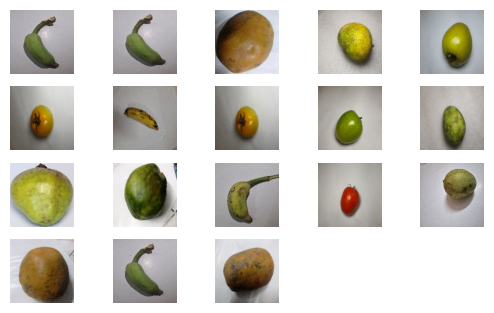

In [47]:
# plot 25 images
for i in range(18):
	plt.subplot(5, 5, 1 + i)
	plt.axis('off')
	img=dataset.next()[0][0]
	img = (img / 2) + 0.5
	img = (img * 255.0).astype(np.uint8)
	plt.imshow(img)
plt.show()

In [48]:

d_model.summary()

Model: "model_9"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_13 (InputLayer)       [(None, 1)]                  0         []                            
                                                                                                  
 embedding_6 (Embedding)     (None, 1, 50)                900       ['input_13[0][0]']            
                                                                                                  
 dense_12 (Dense)            (None, 1, 49152)             2506752   ['embedding_6[0][0]']         
                                                                                                  
 input_14 (InputLayer)       [(None, 128, 128, 3)]        0         []                            
                                                                                            

In [49]:
g_model.summary()

Model: "model_10"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_16 (InputLayer)       [(None, 100)]                0         []                            
                                                                                                  
 input_15 (InputLayer)       [(None, 1)]                  0         []                            
                                                                                                  
 dense_15 (Dense)            (None, 32768)                3309568   ['input_16[0][0]']            
                                                                                                  
 embedding_7 (Embedding)     (None, 1, 50)                900       ['input_15[0][0]']            
                                                                                           

In [50]:
gan_model.summary()

Model: "model_11"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_16 (InputLayer)       [(None, 100)]                0         []                            
                                                                                                  
 input_15 (InputLayer)       [(None, 1)]                  0         []                            
                                                                                                  
 dense_15 (Dense)            (None, 32768)                3309568   ['input_16[0][0]']            
                                                                                                  
 embedding_7 (Embedding)     (None, 1, 50)                900       ['input_15[0][0]']            
                                                                                           

In [61]:
last_trained_till=95

In [109]:
train(g_model, d_model, gan_model, dataset, latent_dim,n_epochs=10,n_batch=64,n_class=18)

Output hidden; open in https://colab.research.google.com to view.

In [102]:
g_model.save(f'{base_folder}/fruit_conditional_generator-140.h5')